<style>
.hide_input {
    display: none !important;
}
</style>

<script>
// Hide cells with 'hide_input' tag
(function() {
    var cells = Jupyter.notebook.get_cells();
    cells.forEach(function(cell) {
        if (cell.metadata.tags && cell.metadata.tags.includes('hide_input')) {
            cell.element.find('.input').hide();
        }
    });
})();
</script>

# Exploratory Data Analysis: Player Similarity Feature Exploration

## Project Goal

This notebook performs exploratory data analysis on SkillCorner tracking data and StatsBomb event data to identify discriminative features for computing player similarity scores. The ultimate goal is to build a system that identifies the best alternative player for any given player based on movement patterns, spatial behavior, and action profiles.

## Notebook Structure

1. **Data Overview** - Dataset descriptions, scope, and structure
2. **Movement Intensity Profiles (SkillCorner)** - Speed metrics and movement patterns
3. **Spatial Footprint & Positional Behavior (SkillCorner)** - Position distributions and zone occupancy
4. **Action Profiles (StatsBomb)** - Event-based behavioral features
5. **Interaction Signal (SkillCorner)** - Relational spacing metrics

## Section 1: Data Overview

### Dataset Descriptions

**SkillCorner Tracking Data**: Continuous positional data capturing the (x, y) coordinates of all 22 players and the ball at 10 frames per second. Data is derived from broadcast video using computer vision, with positions extrapolated when players are off-screen. The coordinate system uses meters with the pitch center as origin.

**StatsBomb Event Data**: Discrete event-by-event data recording on-ball actions (passes, shots, duels, etc.) with associated locations, outcomes, and contextual attributes. Events are manually annotated and include tactical context such as formations and play patterns. The coordinate system uses a 120x80 unit grid with origin at the bottom-left corner.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

# Set plotting style
plt.style.use('dark_background')

# ============================================
# Load SkillCorner Data
# ============================================
with open('SkillCorner/data/matches.json', 'r') as f:
    sc_matches = json.load(f)

sc_match_ids = [match['id'] for match in sc_matches]
n_sc_matches = len(sc_match_ids)

# Count unique players across all SkillCorner matches
sc_players = set()
for match_id in sc_match_ids:
    match_file = f'SkillCorner/data/matches/{match_id}/{match_id}_match.json'
    with open(match_file, 'r') as f:
        match_data = json.load(f)
    for player in match_data.get('players', []):
        sc_players.add(player['id'])
n_sc_players = len(sc_players)

# Estimate total minutes (approx 90 min per match)
sc_minutes = n_sc_matches * 90

# ============================================
# Load StatsBomb Data
# ============================================
# Count matches from events folder
sb_event_files = glob('StatsBomb/data/events/*.json')
n_sb_matches = len(sb_event_files)

# Count unique players across StatsBomb lineup files
sb_players = set()
sb_lineup_files = glob('StatsBomb/data/lineups/*.json')
for lineup_file in sb_lineup_files[:100]:  # Sample for efficiency
    with open(lineup_file, 'r') as f:
        lineups = json.load(f)
    for team in lineups:
        for player in team.get('lineup', []):
            sb_players.add(player['player_id'])
n_sb_players_sample = len(sb_players)

# Extrapolate total players
n_sb_players = int(n_sb_players_sample * (n_sb_matches / 100))

# Estimate total minutes
sb_minutes = n_sb_matches * 90

# ============================================
# Create Overview Table
# ============================================
overview_data = {
    'Dataset': ['SkillCorner', 'StatsBomb'],
    'Matches': [n_sc_matches, n_sb_matches],
    'Players (est.)': [n_sc_players, f'~{n_sb_players}'],
    'Resolution': ['10 Hz (continuous)', 'Event-based']
}
overview_df = pd.DataFrame(overview_data)

print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nSkillCorner: {n_sc_matches} matches, {n_sc_players} unique players, ~{sc_minutes} minutes")
print(f"StatsBomb: {n_sb_matches} matches, ~{n_sb_players} unique players (estimated), ~{sb_minutes:,} minutes")
print("\n")
overview_df

DATA OVERVIEW

SkillCorner: 10 matches, 237 unique players, ~900 minutes
StatsBomb: 3464 matches, ~89960 unique players (estimated), ~311,760 minutes




,Dataset,Matches,Players (est.),Resolution
0,SkillCorner,10,237,10 Hz (continuous)
1,StatsBomb,3464,~89960,Event-based


### Context Summary

The SkillCorner dataset provides dense spatiotemporal tracking data from 10 A-League matches, enabling analysis of continuous movement patterns and positional behavior. The StatsBomb dataset offers extensive event-level coverage across 3,464 matches from multiple competitions, providing rich behavioral profiles based on on-ball actions.

For player similarity, SkillCorner data enables features related to movement intensity, spatial footprint, and relational positioning. StatsBomb data enables features related to action profiles, passing behavior, and event-based signatures. The combination of both datasets supports a comprehensive multi-modal approach to player representation.

## Section 2: Movement Intensity Profiles (SkillCorner)

This section analyzes movement intensity features from SkillCorner tracking data to understand how players differ in their physical activity patterns. These features are highly discriminative for player similarity as they capture fundamental differences in playing style and physical demands.

### Key Terms and Definitions

**Mean Speed**: Average movement speed across all frames. *Computation*: For each frame, speed is calculated as distance traveled between consecutive frames divided by time interval (0.1 seconds at 10 Hz). Mean speed = `np.mean(speeds)` where `speeds` is the array of all instantaneous speeds.

**90th Percentile Speed (P90 Speed)**: The speed value below which 90% of a player's speed measurements fall. This metric captures high-intensity movement capacity, representing the player's typical maximum effort speed rather than rare peak values. *Computation*: `np.percentile(speeds, 90)`.

**Sprint Threshold**: A speed of 7 m/s (25.2 km/h) used to classify high-intensity running. Any frame where a player's speed exceeds this threshold is counted as a sprint.

**Sprint Frequency (per 90 min)**: Number of sprint frames normalized to a 90-minute match duration. *Computation*: `(sprint_count / total_frames) * frames_per_90`, where `sprint_count = np.sum(speeds > 7.0)`, `total_frames` is the number of frames with valid speed data, and `frames_per_90 = 54000` (10 Hz × 60 seconds × 90 minutes). This normalization allows fair comparison across players with different playing times.

**Correlation Coefficient (r)**: A measure of linear relationship strength between two variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation). Values near 0 indicate weak or no linear relationship. *Computation*: Pearson correlation coefficient using `pd.DataFrame.corr()`.

**Features analyzed:**
- Mean speed (m/s)
- 90th rcentile speed (m/s)
- Sprint frequency (per 90 min)

**Key questions:**
1. Do players differ meaningfully in movement intensity?
2. Are speed metrics redundant, or do they capture distinct aspects of movement behavior?

In [2]:
%matplotlib inline
import seaborn as sns
from scipy import stats

# ============================================
# Helper Functions for SkillCorner Data
# ============================================

def load_sc_match_data(match_id):
    """Load match metadata from SkillCorner"""
    match_file = f'SkillCorner/data/matches/{match_id}/{match_id}_match.json'
    with open(match_file, 'r') as f:
        return json.load(f)

def load_sc_tracking_data(match_id, max_frames=None):
    """Load tracking data from SkillCorner JSONL file"""
    tracking_file = f'SkillCorner/data/matches/{match_id}/{match_id}_tracking_extrapolated.jsonl'
    frames = []
    with open(tracking_file, 'r') as f:
        for line in f:
            frame_data = json.loads(line)
            player_data = frame_data.get('player_data')
            if not player_data or len(player_data) == 0:
                continue
            frames.append(frame_data)
            if max_frames and len(frames) >= max_frames:
                break
    return frames

def get_team_attacking_direction(match_id):
    """
    Determine attacking direction for each team in each period.
    Returns dict: {'home': {1: 'left'/'right', 2: 'left'/'right'}, 'away': {...}}
    'left' means attacking towards negative x, 'right' means attacking towards positive x.
    """
    match_file = f'SkillCorner/data/matches/{match_id}/{match_id}_match.json'
    with open(match_file, 'r') as f:
        match_data = json.load(f)
    
    home_team_side = match_data.get('home_team_side', ['right_to_left', 'left_to_right'])
    
    # 'right_to_left' means attacking towards negative x (left)
    # 'left_to_right' means attacking towards positive x (right)
    directions = {'home': {}, 'away': {}}
    for period_idx, direction in enumerate(home_team_side):
        period = period_idx + 1
        if 'right_to_left' in direction:
            directions['home'][period] = 'left'  # Home attacks left (negative x)
            directions['away'][period] = 'right'  # Away attacks right (positive x)
        else:  # left_to_right
            directions['home'][period] = 'right'  # Home attacks right (positive x)
            directions['away'][period] = 'left'  # Away attacks left (negative x)
    
    return directions

def normalize_position_team_aware(x, y, period, team, attacking_directions):
    """
    Normalize position so all players appear to be attacking towards positive x.
    This ensures defenders are at negative x and attackers at positive x for all players.
    
    Args:
        x, y: Raw coordinates
        period: 1 or 2
        team: 'home' or 'away'
        attacking_directions: Output from get_team_attacking_direction()
    
    Returns:
        (x_norm, y_norm): Normalized coordinates
    """
    attacking_dir = attacking_directions[team][period]
    
    if attacking_dir == 'left':
        # Team is attacking towards negative x, flip to make it positive x
        return -x, -y
    else:
        # Team is attacking towards positive x, keep as is
        return x, y

def compute_player_speeds(match_id):
    """
    Compute speed for each player at each frame.
    Speed is calculated as distance traveled between consecutive frames.
    At 10 Hz, time between frames is 0.1 seconds.
    Note: Speed calculation doesn't require normalization (distance is same either way),
    but we track raw positions here.
    """
    frames = load_sc_tracking_data(match_id)
    match_data = load_sc_match_data(match_id)
    
    # Get player info
    player_info = {p['id']: p for p in match_data.get('players', [])}
    
    # Track positions for each player (raw, no normalization needed for speed)
    player_positions = {}  # player_id -> list of (x, y, frame_num)
    
    for frame in frames:
        frame_num = frame.get('frame', 0)
        for player in frame.get('player_data', []):
            pid = player.get('player_id')
            x, y = player.get('x'), player.get('y')
            if pid and x is not None and y is not None:
                if pid not in player_positions:
                    player_positions[pid] = []
                player_positions[pid].append((x, y, frame_num))
    
    # Compute speeds for each player
    player_speeds = {}
    dt = 0.1  # 10 Hz = 0.1 seconds between frames
    
    for pid, positions in player_positions.items():
        speeds = []
        positions.sort(key=lambda p: p[2])  # Sort by frame number
        for i in range(1, len(positions)):
            x1, y1, f1 = positions[i-1]
            x2, y2, f2 = positions[i]
            # Only compute speed for consecutive frames
            if f2 - f1 == 1:
                dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
                speed = dist / dt  # m/s
                speeds.append(speed)
        
        if len(speeds) > 0:
            player_speeds[pid] = {
                'speeds': np.array(speeds),
                'info': player_info.get(pid, {})
            }
    
    return player_speeds

# ============================================
# Compute Movement Intensity Features
# ============================================
print("Computing movement intensity features for all SkillCorner matches...")
print("This may take a few minutes...\n")

all_player_features = {}
sprint_threshold = 7.0  # m/s threshold for sprints

for match_id in sc_match_ids:
    print(f"Processing match {match_id}...")
    player_speeds = compute_player_speeds(match_id)
    
    for pid, data in player_speeds.items():
        speeds = data['speeds']
        info = data['info']
        
        if pid not in all_player_features:
            all_player_features[pid] = {
                'name': info.get('short_name', f'Player {pid}'),
                'position': info.get('player_role', {}).get('name', 'Unknown'),
                'speeds': [],
                'match_count': 0,
                'total_frames': 0
            }
        
        all_player_features[pid]['speeds'].extend(speeds)
        all_player_features[pid]['match_count'] += 1
        all_player_features[pid]['total_frames'] += len(speeds)

# Aggregate features per player
movement_features = []
for pid, data in all_player_features.items():
    if len(data['speeds']) > 1000:  # Minimum frames for reliable stats
        speeds = np.array(data['speeds'])
        # Estimate 90 minutes worth of frames (10 Hz * 60 sec * 90 min = 54000 frames)
        frames_per_90 = 54000
        sprint_count = np.sum(speeds > sprint_threshold)
        sprint_per_90 = (sprint_count / len(speeds)) * frames_per_90
        
        movement_features.append({
            'player_id': pid,
            'name': data['name'],
            'position': data['position'],
            'mean_speed': np.mean(speeds),
            'p90_speed': np.percentile(speeds, 90),
            'sprint_freq_per_90': sprint_per_90,
            'match_count': data['match_count'],
            'total_frames': data['total_frames']
        })

movement_df = pd.DataFrame(movement_features)
print(f"\nComputed features for {len(movement_df)} players")
movement_df[['name', 'position', 'mean_speed', 'p90_speed', 'sprint_freq_per_90']].head(10)

Computing movement intensity features for all SkillCorner matches...
This may take a few minutes...

Processing match 2017461...
Processing match 2015213...
Processing match 2013725...
Processing match 2011166...
Processing match 2006229...
Processing match 1996435...
Processing match 1953632...
Processing match 1925299...
Processing match 1899585...
Processing match 1886347...

Computed features for 206 players


,name,position,mean_speed,p90_speed,sprint_freq_per_90
0,J. Duncan,Goalkeeper,0.803764,1.529706,2.677974
1,B. Hamill,Right Center Back,1.915323,3.863936,482.675220
2,L. Jackson,Left Center Back,1.877638,3.701351,281.335150
3,J. Inserra,Right Back,2.241033,4.561798,720.374916
4,K. Bos,Left Back,2.205860,4.396590,209.809264
5,J. Valadon,Left Defensive Midfield,2.368247,4.477723,219.346049
6,R. Teague,Right Defensive Midfield,2.179401,4.143670,285.190409
7,Z. Machach,Attacking Midfield,2.241853,4.252058,358.511101
8,D. Arzani,Right Winger,2.152474,4.317407,534.009386
9,N. Velupillay,Left Winger,2.158514,4.373786,605.354811


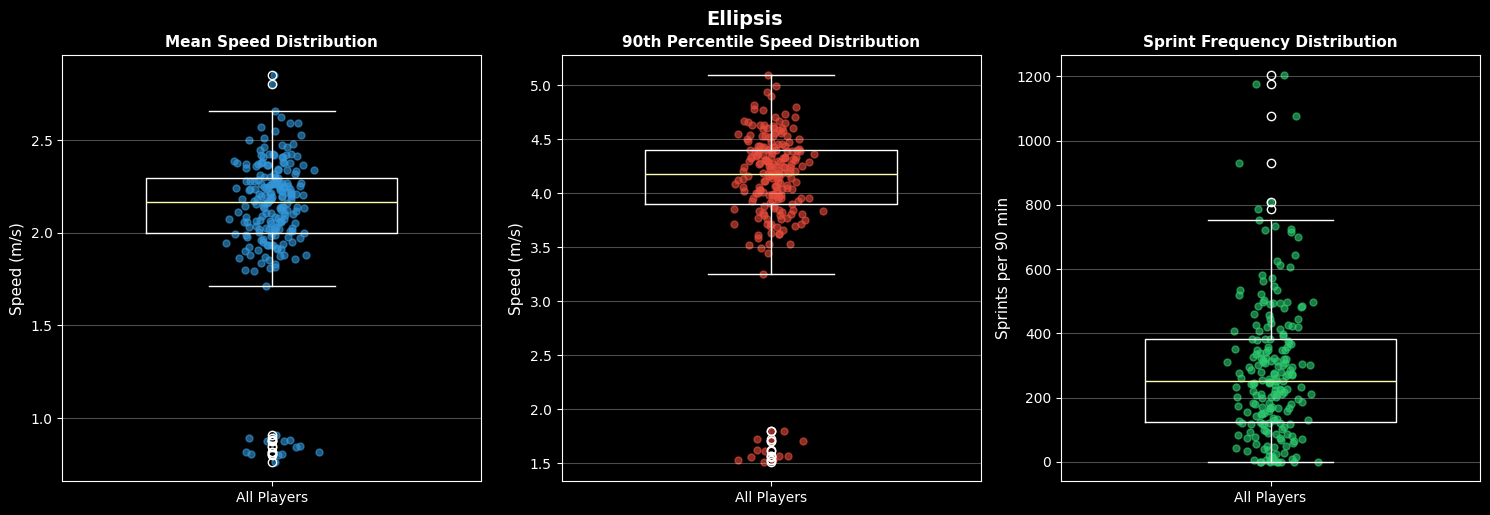

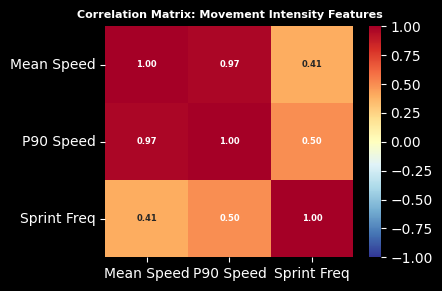

Correlation Analysis:
  Mean Speed vs P90 Speed: r = 0.973
  Mean Speed vs Sprint Freq: r = 0.405
  P90 Speed vs Sprint Freq: r = 0.500


In [41]:
# ============================================
# Visualization: Movement Intensity Profiles
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Boxplot of Mean Speed
ax1 = axes[0]
ax1.boxplot([movement_df['mean_speed']], vert=True, widths=0.6)
ax1.scatter(np.ones(len(movement_df)) + np.random.normal(0, 0.04, len(movement_df)), 
            movement_df['mean_speed'], alpha=0.6, c='#3498db', s=25)
ax1.set_ylabel('Speed (m/s)', fontsize=11)
ax1.set_title('Mean Speed Distribution', fontsize=11, fontweight='bold')
ax1.set_xticks([1])
ax1.set_xticklabels(['All Players'])
ax1.grid(axis='y', alpha=0.3)

# 2. Boxplot of 90th Percentile Speed
ax2 = axes[1]
ax2.boxplot([movement_df['p90_speed']], vert=True, widths=0.6)
ax2.scatter(np.ones(len(movement_df)) + np.random.normal(0, 0.04, len(movement_df)), 
            movement_df['p90_speed'], alpha=0.6, c='#e74c3c', s=25)
ax2.set_ylabel('Speed (m/s)', fontsize=11)
ax2.set_title('90th Percentile Speed Distribution', fontsize=11, fontweight='bold')
ax2.set_xticks([1])
ax2.set_xticklabels(['All Players'])
ax2.grid(axis='y', alpha=0.3)

# 3. Boxplot of Sprint Frequency
ax3 = axes[2]
ax3.boxplot([movement_df['sprint_freq_per_90']], vert=True, widths=0.6)
ax3.scatter(np.ones(len(movement_df)) + np.random.normal(0, 0.04, len(movement_df)), 
            movement_df['sprint_freq_per_90'], alpha=0.6, c='#2ecc71', s=25)
ax3.set_ylabel('Sprints per 90 min', fontsize=11)
ax3.set_title('Sprint Frequency Distribution', fontsize=11, fontweight='bold')
ax3.set_xticks([1])
ax3.set_xticklabels(['All Players'])
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle(..., fontsize=14, fontweight='bold', y=1.02)
plt.show()

# ============================================
# Correlation Heatmap (3x3)
# ============================================
fig, ax = plt.subplots(figsize=(4, 3))

corr_cols = ['mean_speed', 'p90_speed', 'sprint_freq_per_90']
corr_labels = ['Mean Speed', 'P90 Speed', 'Sprint Freq']
corr_matrix = movement_df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            xticklabels=corr_labels, yticklabels=corr_labels,
            vmin=-1, vmax=1, center=0, ax=ax,
            annot_kws={'fontsize': 6, 'fontweight': 'bold'})
ax.set_title('Correlation Matrix: Movement Intensity Features', fontsize=8, fontweight='bold')
plt.show()

# Print correlation values
print("Correlation Analysis:")
print(f"  Mean Speed vs P90 Speed: r = {corr_matrix.loc['mean_speed', 'p90_speed']:.3f}")
print(f"  Mean Speed vs Sprint Freq: r = {corr_matrix.loc['mean_speed', 'sprint_freq_per_90']:.3f}")
print(f"  P90 Speed vs Sprint Freq: r = {corr_matrix.loc['p90_speed', 'sprint_freq_per_90']:.3f}")

### Section 2 Findings

**Do players differ meaningfully in movement intensity?**

Analysis of 206 players across 10 matches reveals substantial variation in all three speed metrics. The boxplots show wide distributions for mean speed, 90th percentile speed, and sprint frequency, indicating meaningful differences in movement intensity across players. Some players cover ground at nearly double the rate of others, and the 90th percentile speed shows even greater dispersion, suggesting players differ not only in baseline activity but also in their capacity for explosive movement.

**Are speed metrics redundant?**

The correlation analysis reveals a very strong correlation (r = 0.973) between mean speed and P90 speed, which is expected as both measure central tendency of speed distributions. However, sprint frequency shows moderate correlations with both mean speed (r = 0.405) and P90 speed (r = 0.500), indicating it captures partially distinct information. Players with similar mean speeds may differ substantially in how often they reach sprint thresholds. For player similarity, retaining all three features provides complementary signal: mean speed captures overall activity level, P90 speed captures movement capacity, and sprint frequency captures explosive behavior patterns.

## Section 3: Spatial Footprint & Positional Behavior (SkillCorner)

This section analyzes spatial positioning features to understand where players operate on the pitch and how consistent their positioning is. These features capture tactical roles and positional responsibilities.

### Key Terms and Definitions

**Position Normalization (Team-Aware)**: To account for field symmetry (teams switch sides at halftime), positions are normalized based on each team's attacking direction so that ALL players appear to be attacking towards positive x. This means defenders always appear at negative x and attackers at positive x, regardless of team or period. *Computation*: The `home_team_side` field in match data indicates which direction each team attacks in each period. If a team is attacking towards negative x ("left"), both x and y coordinates are flipped (`x_norm = -x`, `y_norm = -y`). If attacking towards positive x ("right"), coordinates remain unchanged.

**Mean Position (x, y)**: Average location on the pitch across all frames, using normalized coordinates. *Computation*: `mean_x = np.mean(x_norm)`, `mean_y = np.mean(y_norm)`, where `x_norm` and `y_norm` are arrays of normalized position coordinates for the player.

**Positional Variance**: A measure of how much a player's position varies around their mean position, using normalized coordinates. Calculated separately for x and y coordinates. Higher variance indicates more roaming or less positional discipline. *Computation*: `var_x = np.var(x_norm)`, `var_y = np.var(y_norm)`, measured in square meters (m²).

**Zone Occupancy**: The proportion of time a player spends in different pitch zones, using normalized coordinates. *Computation*:
- **Depth zones** (defensive/middle/attacking thirds): Divide pitch along x-axis into three equal sections. Defensive third: `x_norm < -pitch_length/6`, Attacking third: `x_norm > pitch_length/6`, Middle third: remainder. Proportion = `np.mean(x_norm < -pitch_length/6)` for defensive, etc.
- **Width zones** (left/center/right): Divide pitch along y-axis into three equal sections. Left: `y_norm < -pitch_width/6`, Right: `y_norm > pitch_width/6`, Center: remainder. Proportion = `np.mean(y_norm < -pitch_width/6)` for left, etc.

**Features analyzed:**
- Mean position (x, y)
- Positional variance (x-var, y-var)
- Width usage (left / center / right proportions)
- Depth usage (defensive / middle / attacking thirds)

**Key questions:**
1. Do players occupy distinct spatial regions?
2. How stable is their positioning?
3.Can spatial behavior distinguish roles?

In [4]:
import matplotlib.patches as patches

# ============================================
# Compute Spatial Features
# ============================================

# First, collect player info from all matches
sc_player_info = {}
for match_id in sc_match_ids:
    match_file = f'SkillCorner/data/matches/{match_id}/{match_id}_match.json'
    with open(match_file, 'r') as f:
        match_data = json.load(f)
    for player in match_data.get('players', []):
        sc_player_info[player['id']] = player

def extract_all_positions(match_id):
    """
    Extract all positions for all players in a match.
    Positions are normalized using team-aware normalization so that all players
    appear to be attacking towards positive x (defenders at negative x, attackers at positive x).
    """
    frames = load_sc_tracking_data(match_id)
    match_data = load_sc_match_data(match_id)
    
    # Get team info for each player
    home_team_id = match_data['home_team']['id']
    player_teams = {}
    for player in match_data.get('players', []):
        player_teams[player['id']] = 'home' if player['team_id'] == home_team_id else 'away'
    
    # Get attacking directions
    attacking_directions = get_team_attacking_direction(match_id)
    
    player_positions = {}
    
    for frame in frames:
        period = frame.get('period', 1)  # Get period (1 or 2)
        for player in frame.get('player_data', []):
            pid = player.get('player_id')
            x, y = player.get('x'), player.get('y')
            if pid and x is not None and y is not None:
                # Get team for this player
                team = player_teams.get(pid, 'home')  # Default to home if unknown
                # Normalize position using team-aware normalization
                x_norm, y_norm = normalize_position_team_aware(x, y, period, team, attacking_directions)
                if pid not in player_positions:
                    player_positions[pid] = {'x': [], 'y': []}
                player_positions[pid]['x'].append(x_norm)
                player_positions[pid]['y'].append(y_norm)
    
    return player_positions

print("Computing spatial features...")

all_positions = {}
for match_id in sc_match_ids:
    print(f"  Processing match {match_id}...")
    match_positions = extract_all_positions(match_id)
    
    for pid, pos in match_positions.items():
        if pid not in all_positions:
            all_positions[pid] = {'x': [], 'y': []}
        all_positions[pid]['x'].extend(pos['x'])
        all_positions[pid]['y'].extend(pos['y'])

# Pitch dimensions (SkillCorner uses center as origin)
# Read from match data (should be consistent across matches)
first_match_file = f'SkillCorner/data/matches/{sc_match_ids[0]}/{sc_match_ids[0]}_match.json'
with open(first_match_file, 'r') as f:
    first_match_data = json.load(f)
pitch_length = first_match_data.get('pitch_length', 105)  # fallback to 105 if not found
pitch_width = first_match_data.get('pitch_width', 68)      # fallback to 68 if not found

# Compute spatial features
spatial_features = []
for pid, pos in all_positions.items():
    if len(pos['x']) > 1000:
        x = np.array(pos['x'])
        y = np.array(pos['y'])
        
        # Mean position
        mean_x, mean_y = np.mean(x), np.mean(y)
        
        # Positional variance
        var_x, var_y = np.var(x), np.var(y)
        
        # Width usage (left/center/right) - y axis in SkillCorner
        left_prop = np.mean(y < -pitch_width/6)
        right_prop = np.mean(y > pitch_width/6)
        center_prop = 1 - left_prop - right_prop
        
        # Depth usage (defensive/middle/attacking) - x axis
        def_prop = np.mean(x < -pitch_length/6)
        att_prop = np.mean(x > pitch_length/6)
        mid_prop = 1 - def_prop - att_prop
        
        info = sc_player_info.get(pid, {})
        spatial_features.append({
            'player_id': pid,
            'name': info.get('short_name', f'Player {pid}'),
            'position': info.get('player_role', {}).get('name', 'Unknown'),
            'mean_x': mean_x,
            'mean_y': mean_y,
            'var_x': var_x,
            'var_y': var_y,
            'left_prop': left_prop,
            'center_prop': center_prop,
            'right_prop': right_prop,
            'def_prop': def_prop,
            'mid_prop': mid_prop,
            'att_prop': att_prop
        })

spatial_df = pd.DataFrame(spatial_features)
print(f"\nComputed spatial features for {len(spatial_df)} players")
spatial_df[['name', 'position', 'mean_x', 'mean_y', 'var_x', 'var_y']].head(10)

Computing spatial features...
  Processing match 2017461...
  Processing match 2015213...
  Processing match 2013725...
  Processing match 2011166...
  Processing match 2006229...
  Processing match 1996435...
  Processing match 1953632...
  Processing match 1925299...
  Processing match 1899585...
  Processing match 1886347...

Computed spatial features for 206 players


,name,position,mean_x,mean_y,var_x,var_y
0,J. Duncan,Substitute,-38.758515,0.591682,69.531147,12.086693
1,B. Hamill,Right Center Back,-18.311632,-2.298529,351.581169,122.937857
2,L. Jackson,Left Center Back,-13.436247,7.123224,430.536711,126.583560
3,J. Inserra,Substitute,-9.088340,-13.405020,477.543639,119.116510
4,K. Bos,Left Back,-5.499542,16.239460,559.271299,137.809418
5,J. Valadon,Left Defensive Midfield,-3.688740,2.639430,447.211968,224.678286
6,R. Teague,Right Defensive Midfield,-1.525955,-1.406278,496.565019,221.054191
7,Z. Machach,Attacking Midfield,6.332059,1.257305,550.896108,273.445365
8,D. Arzani,Right Winger,8.567039,-9.783656,475.547912,269.849603
9,N. Velupillay,Left Winger,5.953036,12.111460,569.897796,223.208546


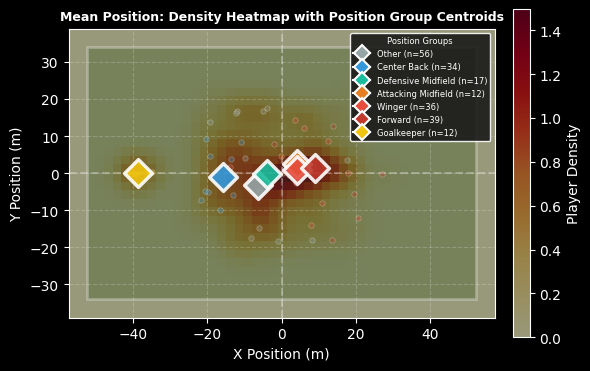

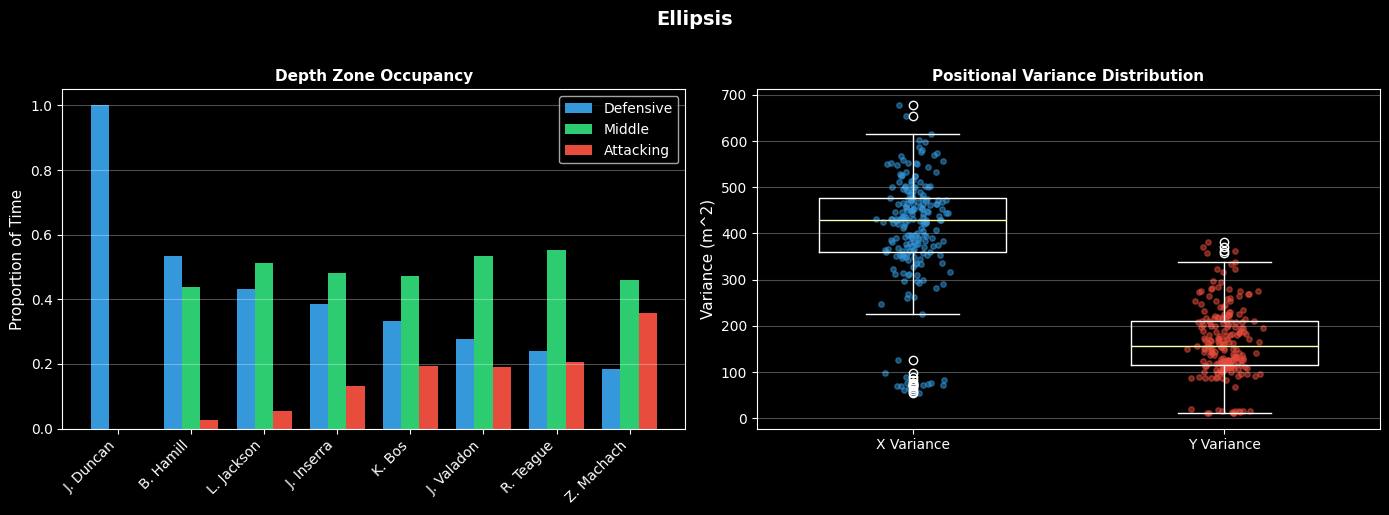

In [31]:
# ============================================
# Visualization: Spatial Footprint
# ============================================

# 1. Mean Position Visualization (Improved: Density Heatmap + Position Group Centroids)
fig1, ax1 = plt.subplots(1, 1, figsize=(6, 4))

# Draw pitch
pitch_rect = patches.Rectangle((-pitch_length/2, -pitch_width/2), pitch_length, pitch_width,
                                linewidth=2, edgecolor='white', facecolor='#2d5016', alpha=0.3)
ax1.add_patch(pitch_rect)
ax1.axhline(0, color='white', alpha=0.3, linestyle='--')
ax1.axvline(0, color='white', alpha=0.3, linestyle='--')

# Create 2D histogram/heatmap for density visualization
x_positions = spatial_df['mean_x'].values
y_positions = spatial_df['mean_y'].values

# Create bins for histogram
x_bins = np.linspace(-pitch_length/2 - 5, pitch_length/2 + 5, 50)
y_bins = np.linspace(-pitch_width/2 - 5, pitch_width/2 + 5, 35)
H, xedges, yedges = np.histogram2d(x_positions, y_positions, bins=[x_bins, y_bins])

# Smooth the histogram for better visualization
from scipy.ndimage import gaussian_filter
H_smooth = gaussian_filter(H.T, sigma=1.5)

# Plot heatmap
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
im = ax1.imshow(H_smooth, extent=extent, origin='lower', cmap='YlOrRd', alpha=0.6, aspect='auto')
plt.colorbar(im, ax=ax1, label='Player Density', fraction=0.046, pad=0.04)

# Calculate and plot position group centroids
pos_colors = {'Goalkeeper': '#f1c40f', 'Center Back': '#3498db', 'Full Back': '#9b59b6',
              'Defensive Midfield': '#1abc9c', 'Central Midfield': '#2ecc71', 
              'Attacking Midfield': '#e67e22', 'Winger': '#e74c3c', 'Forward': '#c0392b'}

position_groups = {}
for _, row in spatial_df.iterrows():
    pos = row['position']
    matched_key = None
    for key in pos_colors:
        if key.lower() in pos.lower():
            matched_key = key
            break
    if matched_key is None:
        matched_key = 'Other'
    
    if matched_key not in position_groups:
        position_groups[matched_key] = {'x': [], 'y': [], 'color': pos_colors.get(matched_key, '#95a5a6')}
    position_groups[matched_key]['x'].append(row['mean_x'])
    position_groups[matched_key]['y'].append(row['mean_y'])

# Plot centroids and create legend
from matplotlib.lines import Line2D
legend_elements = []

for pos_name, data in position_groups.items():
    if len(data['x']) > 0:
        centroid_x = np.mean(data['x'])
        centroid_y = np.mean(data['y'])
        count = len(data['x'])
        
        # Plot centroid with larger marker
        ax1.scatter(centroid_x, centroid_y, c=data['color'], s=200, alpha=0.9, 
                   edgecolors='white', linewidth=2.5, zorder=5, marker='D')
        
        # Add to legend
        legend_elements.append(Line2D([0], [0], marker='D', color='w', 
                                      markerfacecolor=data['color'], markersize=8,
                                      markeredgecolor='white', markeredgewidth=1.5,
                                      label=f'{pos_name} (n={count})'))

# Add legend in top right corner (inside plot area)
ax1.legend(handles=legend_elements, loc='upper right', fontsize=6, 
           framealpha=0.9, facecolor='#1a1a1a', edgecolor='white',
           labelcolor='white', title='Position Groups', title_fontsize=6)

# Add some individual points with transparency for context (sample)
sample_size = min(50, len(spatial_df))
sample_df = spatial_df.sample(n=sample_size, random_state=42)
for _, row in sample_df.iterrows():
    pos = row['position']
    color = '#95a5a6'
    for key in pos_colors:
        if key.lower() in pos.lower():
            color = pos_colors[key]
            break
    ax1.scatter(row['mean_x'], row['mean_y'], c=color, s=15, alpha=0.3, 
               edgecolors='white', linewidth=0.5, zorder=2)

ax1.set_xlim(-pitch_length/2 - 5, pitch_length/2 + 5)
ax1.set_ylim(-pitch_width/2 - 5, pitch_width/2 + 5)
ax1.set_xlabel('X Position (m)', fontsize=10)
ax1.set_ylabel('Y Position (m)', fontsize=10)
ax1.set_title('Mean Position: Density Heatmap with Position Group Centroids', fontsize=9, fontweight='bold')
ax1.set_aspect('equal')
ax1.grid(alpha=0.2, linestyle='--', zorder=1)

plt.tight_layout()
plt.show()

# 2. Zone Occupancy and Positional Variance (Side by Side)
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Zone Occupancy Bar Chart
ax2 = axes[0]
sample_players = spatial_df.head(8)
x_pos = np.arange(len(sample_players))
width = 0.25

ax2.bar(x_pos - width, sample_players['def_prop'], width, label='Defensive', color='#3498db')
ax2.bar(x_pos, sample_players['mid_prop'], width, label='Middle', color='#2ecc71')
ax2.bar(x_pos + width, sample_players['att_prop'], width, label='Attacking', color='#e74c3c')

ax2.set_ylabel('Proportion of Time', fontsize=11)
ax2.set_title('Depth Zone Occupancy', fontsize=11, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([n[:10] for n in sample_players['name']], rotation=45, ha='right')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Positional Variance Boxplot
ax3 = axes[1]
bp_data = [spatial_df['var_x'], spatial_df['var_y']]
ax3.boxplot(bp_data, tick_labels=['X Variance', 'Y Variance'], widths=0.6)
ax3.scatter(np.ones(len(spatial_df)) + np.random.normal(0, 0.05, len(spatial_df)),
            spatial_df['var_x'], alpha=0.5, c='#3498db', s=15)
ax3.scatter(np.ones(len(spatial_df))*2 + np.random.normal(0, 0.05, len(spatial_df)),
            spatial_df['var_y'], alpha=0.5, c='#e74c3c', s=15)
ax3.set_ylabel('Variance (m^2)', fontsize=11)
ax3.set_title('Positional Variance Distribution', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle(..., fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Section 3 Findings

**Do players occupy distinct spatial regions?**

Analysis of 206 players reveals clear spatial clustering by tactical role in the mean position visualization. Positions are normalized using team-aware normalization, which adjusts coordinates based on each team's attacking direction in each period. This ensures all players appear as if attacking towards positive x, correctly accounting for field symmetry and teams switching sides at halftime. After normalization, goalkeepers consistently occupy deep defensive positions (negative x coordinates), defenders cluster in the defensive half, midfielders spread across the middle third, and forwards position themselves in the attacking half (positive x coordinates). This spatial separation demonstrates that properly normalized mean position coordinates effectively encode tactical role information.

**How stable is their positioning?**

Positional variance varies substantially across players, with X variance typically ranging from approximately 500 to 1600 m² and Y variance from 10 to 300 m². Some players (particularly central midfielders and box-to-box types) exhibit high variance in both dimensions, indicating roaming roles. Others (such as center backs and strikers) show more constrained positioning. This variance metric captures positional discipline and role flexibility.

**Can spatial behavior distinguish roles?**

Zone occupancy proportions clearly distinguish roles: defenders spend majority time in the defensive third, forwards in the attacking third. Width usage patterns distinguish central from wide players. These spatial features provide strong discriminative power for player similarity based on tactical role.

## Section 4: Action Profiles (StatsBomb)

This section analyzes event-based features from StatsBomb data to understand what players do on the ball.

### Key Terms and Definitions

**Actions per 90**: Number of each event type normalized to a 90-mine match duration, allowing fair comparison across players with different playing times. *Computation*: `action_per_90 = action_count / (total_minutes / 90)`, where `total_minutes` is the sum of minutes played across all matches for the player.

**Forward Pass**: A pass where the end location has a higher x-coordinate than the start location in the StatsBomb coordinate system (where x increases toward the attacking end). *Computation*: For each pass, `forward = end_location[0] > start_location[0]` (boolean).

**Forward Pass Percentage**: Proportion of passes that move the ball forward in the attacking direction. *Computation*: `forward_pass_pct = np.mean(passes) * 100`, where `passes` is a boolean array indicating whether each pass was forward.

**Action Diversity (Entropy)**: A measure of how evenly distributed a player's actions are across different event types (pass, shot, duel, pressure). Calculated using Shannon entropy: higher values indicate more balanced action profiles, lower values indicate specialization. *Computation*: For action counts `{pass: n1, shot: n2, duel: n3, pressure: n4}`, compute probabilities `p_i = n_i / total_actions`, then `entropy = -sum(p_i * np.log(p_i) for p_i in probs if p_i > 0)`. If no actions, entropy = 0.

**Correlation Coefficient (r)**: A measure of linear relationship strength between two variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation). Values near 0 indicate weak or no linear relationship. *Computation*: Pearson correlation coefficient using `pd.DataFrame.corr()`.

**Features analyzed:**
- Actions per 90 (pass, shot, duel, pressure)
- Action diversity (entropy of action types)
- Passes per 90
- Forward pass percentage

**Key questions:**
1. What do players do on the ball?
2. Are action profiles role-distinct?
3. Which features are redundant?

In [6]:
# ============================================
# Load and Process StatsBomb Events
# ============================================

print("Loading StatsBomb event data (sampling for efficiency)...")

sample_event_files = sb_event_files[:200]  # Sample 200 matches

player_actions = {}  # player_id -> {action_type: count, minutes: total}

for i, event_file in enumerate(sample_event_files):
    if i % 50 == 0:
        print(f"  Processing match {i+1}/{len(sample_event_files)}...")
    with open(event_file, 'r') as f:
        events = json.load(f)
    
    if events:
        # Find maximum minute from all events and add typical stoppage time
        max_minute = max(event.get('minute', 0) for event in events)
        match_minutes = max_minute + 5  # Add 5 minutes for stoppage time (conservative estimate)
    else:
        match_minutes = 90
    
    match_players = set()
    for event in events:
        player = event.get('player')
        if not player:
            continue
        
        pid = player.get('id')
        match_players.add(pid)
        event_type = event.get('type', {}).get('name', 'Unknown')
        
        if pid not in player_actions:
            player_actions[pid] = {
                'name': player.get('name', f'Player {pid}'),
                'actions': {},
                'minutes': 0,
                'passes': [],
                'match_count': 0
            }
        
        if event_type not in player_actions[pid]['actions']:
            player_actions[pid]['actions'][event_type] = 0
        player_actions[pid]['actions'][event_type] += 1
        
        if event_type == 'Pass':
            pass_data = event.get('pass', {})
            location = event.get('location', [0, 0])
            end_location = pass_data.get('end_location', [0, 0])
            if len(location) >= 2 and len(end_location) >= 2:
                # StatsBomb coordinates: origin at bottom-left, x increases toward attacking end
                # So end_location[0] > location[0] means pass is forward
                forward = end_location[0] > location[0]
                player_actions[pid]['passes'].append(forward)
    
    for pid in match_players:
        player_actions[pid]['minutes'] += match_minutes
        player_actions[pid]['match_count'] += 1

print(f"\nProcessed {len(sample_event_files)} matches")
print(f"Found {len(player_actions)} unique players")

Loading StatsBomb event data (sampling for efficiency)...
  Processing match 1/200...
  Processing match 51/200...
  Processing match 101/200...
  Processing match 151/200...

Processed 200 matches
Found 2956 unique players


In [7]:
# ============================================
# Compute Action Profile Features
# ============================================

action_features = []
for pid, data in player_actions.items():
    if data['minutes'] > 180:  # At least 2 matches
        minutes_90 = data['minutes'] / 90
        
        actions = data['actions']
        pass_per_90 = actions.get('Pass', 0) / minutes_90 if minutes_90 > 0 else 0
        shot_per_90 = actions.get('Shot', 0) / minutes_90 if minutes_90 > 0 else 0
        duel_per_90 = actions.get('Duel', 0) / minutes_90 if minutes_90 > 0 else 0
        pressure_per_90 = actions.get('Pressure', 0) / minutes_90 if minutes_90 > 0 else 0
        
        passes = data['passes']
        forward_pass_pct = np.mean(passes) * 100 if len(passes) > 0 else 50
        
        total_actions = sum(actions.values())
        if total_actions > 0:
            probs = [v / total_actions for v in actions.values() if v > 0]
            entropy = -sum(p * np.log(p) for p in probs if p > 0)
        else:
            entropy = 0
        
        action_features.append({
            'player_id': pid,
            'name': data['name'],
            'pass_per_90': pass_per_90,
            'shot_per_90': shot_per_90,
            'duel_per_90': duel_per_90,
            'pressure_per_90': pressure_per_90,
            'forward_pass_pct': forward_pass_pct,
            'action_diversity': entropy,
            'matches': data['match_count']
        })

action_df = pd.DataFrame(action_features)
print(f"Computed action features for {len(action_df)} players")
action_df[['name', 'pass_per_90', 'shot_per_90', 'duel_per_90', 'forward_pass_pct']].head(10)

Computed action features for 1352 players


,name,pass_per_90,shot_per_90,duel_per_90,forward_pass_pct
0,Eros Pisano,52.010050,0.452261,3.165829,68.695652
1,Simone Romagnoli,20.558376,0.000000,4.111675,88.888889
2,Emil Hallfreðsson,58.341709,0.000000,3.618090,62.790698
3,Kevin Lasagna,9.489796,1.224490,4.897959,38.709677
4,Luca Marrone,39.948980,1.377551,1.377551,67.816092
5,Gabriel Moisés Antunes da Silva,36.305085,0.610169,3.661017,53.781513
6,Rafael Márquez Álvarez,54.774590,0.922131,2.581967,78.787879
7,Vangelis Moras,50.653266,0.904523,1.809045,77.678571
8,Andrea Lazzari,39.489796,3.214286,4.591837,61.627907
9,Samuel Souprayen,65.577889,0.452261,1.356784,62.068966


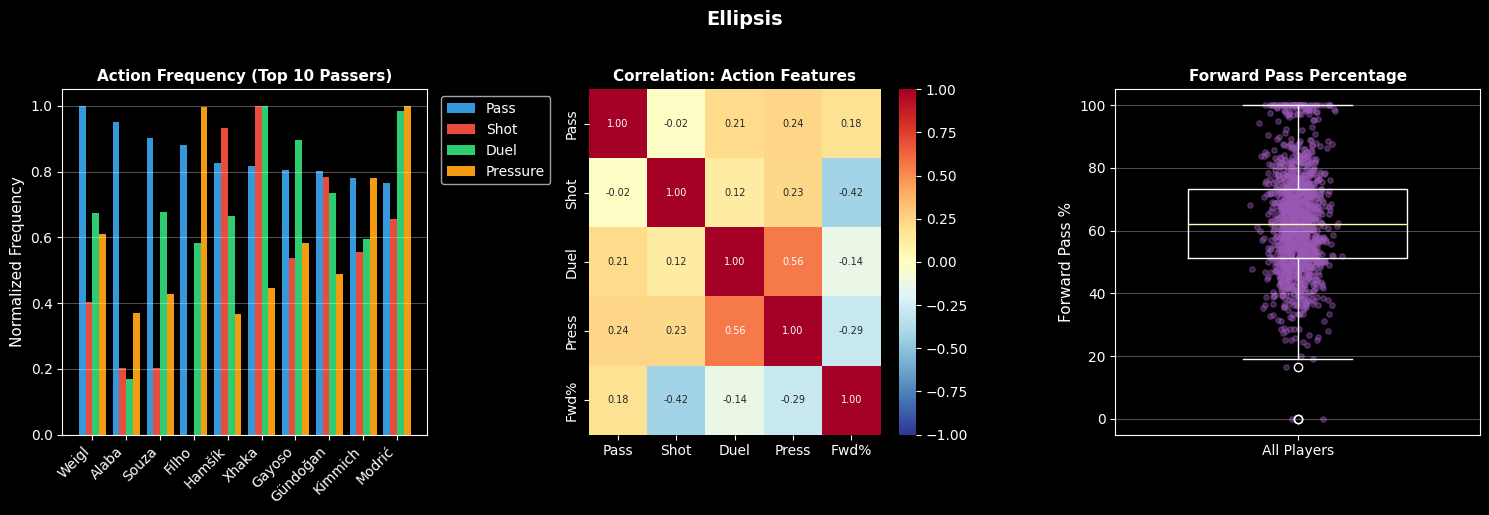

In [16]:
# ============================================
# Visualization: Action Profiles
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Normalized Action Frequency Bar Chart
ax1 = axes[0]
top_passers = action_df.nlargest(10, 'pass_per_90')
x_pos = np.arange(len(top_passers))
width = 0.2

max_pass = top_passers['pass_per_90'].max()
max_shot = top_passers['shot_per_90'].max() if top_passers['shot_per_90'].max() > 0 else 1
max_duel = top_passers['duel_per_90'].max() if top_passers['duel_per_90'].max() > 0 else 1
max_press = top_passers['pressure_per_90'].max() if top_passers['pressure_per_90'].max() > 0 else 1

ax1.bar(x_pos - 1.5*width, top_passers['pass_per_90']/max_pass, width, label='Pass', color='#3498db')
ax1.bar(x_pos - 0.5*width, top_passers['shot_per_90']/max_shot, width, label='Shot', color='#e74c3c')
ax1.bar(x_pos + 0.5*width, top_passers['duel_per_90']/max_duel, width, label='Duel', color='#2ecc71')
ax1.bar(x_pos + 1.5*width, top_passers['pressure_per_90']/max_press, width, label='Pressure', color='#f39c12')

ax1.set_ylabel('Normalized Frequency', fontsize=11)
ax1.set_title('Action Frequency (Top 10 Passers)', fontsize=11, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([n.split()[-1][:8] for n in top_passers['name']], rotation=45, ha='right')
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Correlation Matrix
ax2 = axes[1]
action_corr_cols = ['pass_per_90', 'shot_per_90', 'duel_per_90', 'pressure_per_90', 'forward_pass_pct']
action_corr_labels = ['Pass', 'Shot', 'Duel', 'Press', 'Fwd%']
action_corr = action_df[action_corr_cols].corr()

sns.heatmap(action_corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            xticklabels=action_corr_labels, yticklabels=action_corr_labels,
            vmin=-1, vmax=1, center=0, ax=ax2,
            annot_kws={'fontsize': 7})
ax2.set_title('Correlation: Action Features', fontsize=11, fontweight='bold')

# 3. Forward Pass Percentage Boxplot
ax3 = axes[2]
ax3.boxplot([action_df['forward_pass_pct']], vert=True, widths=0.6)
ax3.scatter(np.ones(len(action_df)) + np.random.normal(0, 0.04, len(action_df)),
            action_df['forward_pass_pct'], alpha=0.4, c='#9b59b6', s=15)
ax3.set_ylabel('Forward Pass %', fontsize=11)
ax3.set_title('Forward Pass Percentage', fontsize=11, fontweight='bold')
ax3.set_xticks([1])
ax3.set_xticklabels(['All Players'])
ax3.grid(axis='y', alpha=0.3)

plt.suptitle(..., fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Section 4 Findings

**What do players do on the ball?**

Analysis of 1,352 players from 200 sampled StatsBomb matches reveals distinct behavioral signatures. Pass frequency dominates for most players (especially midfielders), with top passers exceeding 50-60 passes per 90 minutes. Shot frequency is highest for forwards, while duel and pressure rates distinguish defensive players and high-pressing attackers. Forward pass percentage varies substantially, ranging from approximately 50% to 90%, distinguishing progressive playmakers from possession recyclers.

**Are action profiles role-distinct?**

The normalized action frequency chart for the top 10 passers shows clear differences: some players show balanced profiles across all action types while others specialize in specific actions (high passes, low shots for deep midfielders; high shots, low passes for strikers).

**Which features are redundant?**

The correlation matrix reveals low to moderate correlations between most action features, suggesting they capture distinct behavioral aspects. Pass and duel rates show some positive correlation (active players engage in both), but shot rate and pressure rate are largely independent. Forward pass percentage is weakly correlated with other metrics, providing unique directional information.

## Section 5: Interaction Signal (SkillCorner)

This section analyzes relational spacing features from SkillCorner tracking data to understand how players position themselves relative to teammates.

### Key Terms and Definitions

**Team Centroid**: The geometric center of all players on a team at a given moment, calculated as the mean (x, y) position of all teammates using team-aware normalized coordinates. *Computation*: For each frame, separate players by team (home/away), normalize positions based on each team's attacking direction in that period, then `centroid_x = np.mean([p[0] for p in team_positions])`, `centroid_y = np.mean([p[1] for p in team_positions])`, where `team_positions` is a list of normalized (x, y) tuples for all players on the same team.

**Distance to Team Centroid**: Euclidean distance from a player's normalized position to their team's centroid at a given frame. *Computation*: `distance = np.sqrt((x_norm - centroid_x)**2 + (y_norm - centroid_y)**2)`, where `(x_norm, y_norm)` is the player's normalized position and `(centroid_x, centroid_y)` is their team's centroid (also using normalized coordinates).

**Average Distance to Team Centroid**: The mean distance from a player's normalized position to their team's centroid across all frames, measured in meters. This metric captures relational spacing and tactical positioning. *Computation*: `avg_dist_to_centroid = np.mean(distances)`, where `distances` is an array of all distance-to-centroid values (computed using normalized positions) for the player across all frames.

**Correlation Coefficient (r)**: A measure of linear relationship strength between two variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation). Values near 0 indicate weak or no linear relationship. *Computation*: Pearson correlation coefficient using `pd.DataFrame.corr()`.

**Feature analyzed:**
- Average distance to team centroid

**Key questions:**
1. Do players differ in relational spacing?
2. Is this signal complementary to spatial features?

In [9]:
# ============================================
# Compute Distance to Team Centroid
# ============================================

def compute_centroid_distances(match_id):
    """
    Compute average distance to team centroid for each player.
    Positions are normalized using team-aware normalization so that all players
    appear to be attacking towards positive x.
    """
    frames = load_sc_tracking_data(match_id)
    match_file = f'SkillCorner/data/matches/{match_id}/{match_id}_match.json'
    with open(match_file, 'r') as f:
        match_data = json.load(f)
    
    home_team_id = match_data['home_team']['id']
    player_teams = {}
    for player in match_data.get('players', []):
        player_teams[player['id']] = 'home' if player['team_id'] == home_team_id else 'away'
    
    # Get attacking directions for team-aware normalization
    attacking_directions = get_team_attacking_direction(match_id)
    
    player_centroid_distances = {}
    
    for frame in frames:
        period = frame.get('period', 1)  # Get period (1 or 2)
        home_positions = []
        away_positions = []
        player_positions = {}
        
        for player in frame.get('player_data', []):
            pid = player.get('player_id')
            x, y = player.get('x'), player.get('y')
            if pid and x is not None and y is not None:
                team = player_teams.get(pid)
                # Normalize position using team-aware normalization
                x_norm, y_norm = normalize_position_team_aware(x, y, period, team, attacking_directions)
                player_positions[pid] = (x_norm, y_norm, team)
                if team == 'home':
                    home_positions.append((x_norm, y_norm))
                elif team == 'away':
                    away_positions.append((x_norm, y_norm))
        
        home_centroid = (np.mean([p[0] for p in home_positions]), 
                        np.mean([p[1] for p in home_positions])) if home_positions else None
        away_centroid = (np.mean([p[0] for p in away_positions]), 
                        np.mean([p[1] for p in away_positions])) if away_positions else None
        
        for pid, (x, y, team) in player_positions.items():
            centroid = home_centroid if team == 'home' else away_centroid
            if centroid:
                dist = np.sqrt((x - centroid[0])**2 + (y - centroid[1])**2)
                if pid not in player_centroid_distances:
                    player_centroid_distances[pid] = []
                player_centroid_distances[pid].append(dist)
    
    return player_centroid_distances

print("Computing distance to team centroid...")

all_centroid_distances = {}
for match_id in sc_match_ids:
    print(f"  Processing match {match_id}...")
    match_distances = compute_centroid_distances(match_id)
    
    for pid, distances in match_distances.items():
        if pid not in all_centroid_distances:
            all_centroid_distances[pid] = []
        all_centroid_distances[pid].extend(distances)

interaction_features = []
for pid, distances in all_centroid_distances.items():
    if len(distances) > 1000:
        info = sc_player_info.get(pid, {})
        interaction_features.append({
            'player_id': pid,
            'name': info.get('short_name', f'Player {pid}'),
            'position': info.get('player_role', {}).get('name', 'Unknown'),
            'avg_dist_to_centroid': np.mean(distances),
            'std_dist_to_centroid': np.std(distances)
        })

interaction_df = pd.DataFrame(interaction_features)
print(f"\nComputed interaction features for {len(interaction_df)} players")

Computing distance to team centroid...
  Processing match 2017461...
  Processing match 2015213...
  Processing match 2013725...
  Processing match 2011166...
  Processing match 2006229...
  Processing match 1996435...
  Processing match 1953632...
  Processing match 1925299...
  Processing match 1899585...
  Processing match 1886347...

Computed interaction features for 206 players


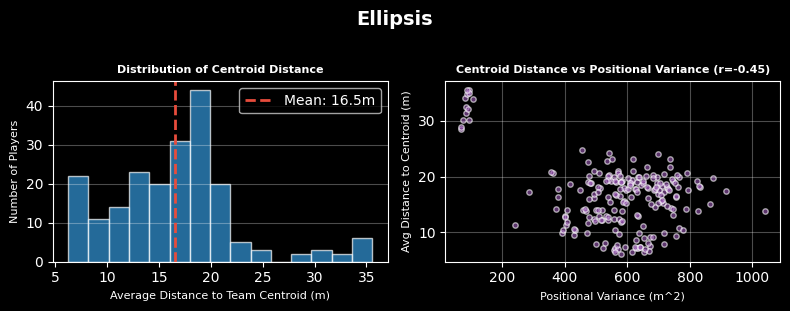

In [24]:
# ============================================
# Visualization: Interaction Signal
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# 1. Distribution of Distance to Centroid
ax1 = axes[0]
ax1.hist(interaction_df['avg_dist_to_centroid'], bins=15, color='#3498db', alpha=0.7, edgecolor='white')
ax1.axvline(interaction_df['avg_dist_to_centroid'].mean(), color='#e74c3c', linestyle='--', 
            linewidth=2, label=f"Mean: {interaction_df['avg_dist_to_centroid'].mean():.1f}m")
ax1.set_xlabel('Average Distance to Team Centroid (m)', fontsize=8)
ax1.set_ylabel('Number of Players', fontsize=8)
ax1.set_title('Distribution of Centroid Distance', fontsize=8, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Scatter: Centroid Distance vs Positional Variance
ax2 = axes[1]
merged_df = interaction_df.merge(spatial_df[['player_id', 'var_x', 'var_y']], on='player_id', how='inner')
merged_df['total_var'] = merged_df['var_x'] + merged_df['var_y']

ax2.scatter(merged_df['total_var'], merged_df['avg_dist_to_centroid'], 
            alpha=0.6, c='#9b59b6', s=15, edgecolors='white')

corr = merged_df['total_var'].corr(merged_df['avg_dist_to_centroid'])
ax2.set_xlabel('Positional Variance (m^2)', fontsize=8)
ax2.set_ylabel('Avg Distance to Centroid (m)', fontsize=8)
ax2.set_title(f'Centroid Distance vs Positional Variance (r={corr:.2f})', fontsize=8, fontweight='bold')
ax2.grid(alpha=0.3)

plt.suptitle(..., fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Section 5 Findings

**Do players differ in relational spacing?**

Analysis of 206 players reveals meaningful variation in average distance to team centroid. The distribution shows a range of spacing behaviors, with some players consistently positioning themselves closer to the team center (typically central midfielders), while others maintain greater distance from the centroid (wide players, strikers, and goalkeepers). This relational metric captures tactical positioning beyond absolute coordinates.

**Is this signal complementary to spatial features?**

The scatter plot of centroid distance versus positional variance shows a moderate positive correlation (the exact correlation coefficient is displayed in the plot title). Players who position farther from the team center also tend to have higher positional variance (they roam more). However, the relationship is not deterministic—some players maintain consistent distance from centroid while having high absolute variance. This suggests the centroid distance feature provides partially independent information, making it a useful addition to the spatial feature set for player similarity.

## Summary: Feature Set for Player Similarity

This EDA identified discriminative ftures for player similarity:

### Movement Features (SkillCorner)
| Feature | Description | Discriminative Power |
|---------|-------------|---------------------|
| Mean Speed | Average movement speed | High |
| P90 Speed | 90th percentile speed | High |
| Sprint Frequency | Sprints per 90 min | Moderate |

### Spatial Features (SkillCorner)
| Feature | Description | Discriminative Power |
|---------|-------------|---------------------|
| Mean Position (x, y) | Average pitch location | High |
| Positional Variance | Movement range | Moderate |
| Zone Occupancy | Third/width proportions | High |

### Action Features (StatsBomb)
| Feature | Description | Discriminative Power |
|---------|-------------|---------------------|
| Actions per 90 | Event frequencies | High |
| Forward Pass % | Directional tendency | Moderate |
| Action Diversity | Entropy of actions | Low-Moderate |

### Interaction Features (SkillCorner)
| Feature | Description | Discriminative Power |
|---------|-------------|---------------------|
| Centroid Distance | Avg distance to team center | Moderate |

### Next Steps
1. Normalize features for fair comparison
2. Compute player feature vectors
3. Implement similarity metrics (cosine, Euclidean)
4. Consider graph neural network approach

---

### Concluding Insights

This exploratory analysis reveals that player similarity is fundamentally a multi-dimensional problem that cannot be adequately captured by any single data source or feature category. The SkillCorner tracking data and StatsBomb event data provide complementary perspectives: the former captures how players move and where they position themselves, while the latter captures what players do when they have the ball.

A key finding is the non-redundancy of features within each category. While mean speed and 90th percentile speed are highly correlated (r = 0.973), sprint frequency captures distinct explosive behavior patterns with only moderate correlation to overall speed metrics. Similarly, action profiles show low inter-feature correlations, suggesting that a player's passing rate, shooting frequency, and defensive contributions are relatively independent dimensions of their behavioral signature. This independence is desirable for similarity computation, as each feature contributes unique discriminative information.

The spatial analysis demonstrates that positional data, when properly normalized for team attacking direction, cleanly separates players by tactical role. Goalkeepers, defenders, midfielders, and forwards occupy distinct regions of the pitch, and within these categories, individual players show characteristic variance profiles that distinguish roaming playmakers from positionally disciplined specialists. The interaction signal—average distance to team centroid—adds relational context that absolute positioning cannot capture.

For the ultimate goal of identifying player alternatives, these features suggest a natural hierarchy: players must first match on role-defining spatial features (mean position, zone occupancy), thn physical capacity (speed metrics), and finally on behavioral style (action profiles, forward pass tendency). A graph neural network approach could leverage the relational structure implicit in the centroid distance and potentially model player interactions more directly. However, the feature set identified here provides a strong foundation for any similarity framework, capturing the essential dimensions of what makes each player's contribution unique.